In [3]:
# titulo DIKW_Netflix
# fecha 21 de mayo
# objetivo generacion del conocimiento mediente el modelo DIWK

# 1 carga y exploracion del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("netflix_titles.csv")

In [5]:
# mostrar las primeras filas
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [6]:
# mostrar las dimensiones
df.ndim

2

In [21]:
len(df)

8807

In [9]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
# mostrar los nombres de columnas 
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [18]:
# mostrar tipos de datos
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [19]:
# 2 limpieza de los datos

# identificar valores nulos
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [20]:
# calcular el porcentaje de los valores faltantes

# o sea dividir entre el total y multiplcar por 100
df.isnull().sum() / len(df) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [22]:
# detectar registros duplicados
df.duplicated().sum()

np.int64(0)

In [23]:
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [29]:
# aplicar eliminacion, transformación.

# 1
df.dropna(subset=['rating', 'duration'], inplace=True)

In [31]:
# 2
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0]) 

In [32]:
# 3
df['director'] = df['director'].fillna('No Data')
df['cast'] = df['cast'].fillna('No Data')
df['country'] = df['country'].fillna('No Data')

In [33]:
# verificar que se quitaron los nulos
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [34]:
# justificacion

# 1. eliminar las filas con rating y duration que son nulos porque son textos, en cuanto a duration, es dificil rellenarlo con moda o promedio por el tema de cancelaciones, ya que ejemplos de datos, unos vienen con minutos, otros con textos por temporadas, etc y en cuanto a reating son solo 4 items y seria peligroso rellenar pues se corre el riesgo al hacer un analisis despues de mostrar peliculas de alguna saga familiar con clasificacion +18 , etc

# 2. rellenar con la moda el date_added pues son solo 10 items donde la moda puede ayudar a rellenar, pues cuando mas veces se estrenaron cosas, mas probable es que esos 10 se hayan estrenado 

# 3. rellenar con texto "No Data" a director, cast y country que representan un buen % del dataset siento el 
#director        29.90%
#cast             9.36%
#country          9.43%

In [35]:
#verificamos que se elimino 
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

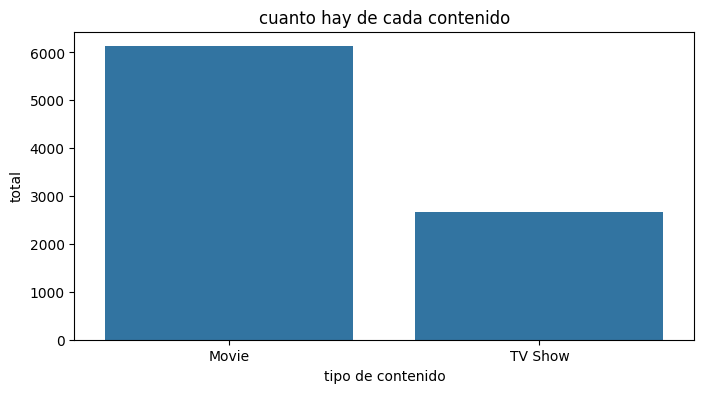

In [37]:
# 3. Analisis descriptivo (CAPA DE INFORMACION)

# Generar al menos 4 graficas.

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="type")

plt.title("cuanto hay de cada contenido")
plt.xlabel("tipo de contenido")
plt.ylabel("total")

plt.show()

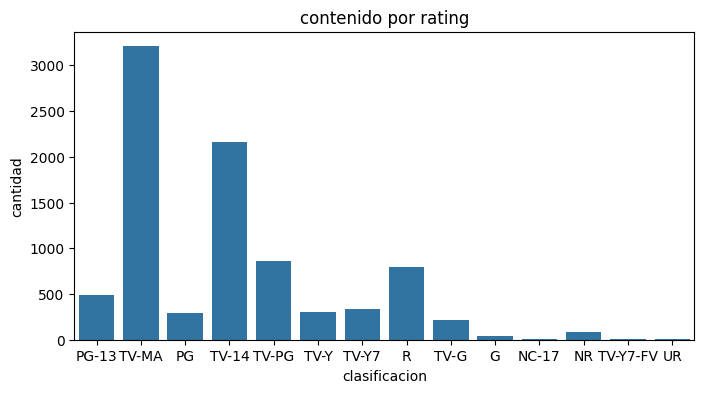

In [40]:

plt.figure(figsize=(8,4))

sns.countplot(data=df, x="rating")

plt.title("contenido por rating")
plt.xlabel("clasificacion")
plt.ylabel("cantidad")

plt.show()

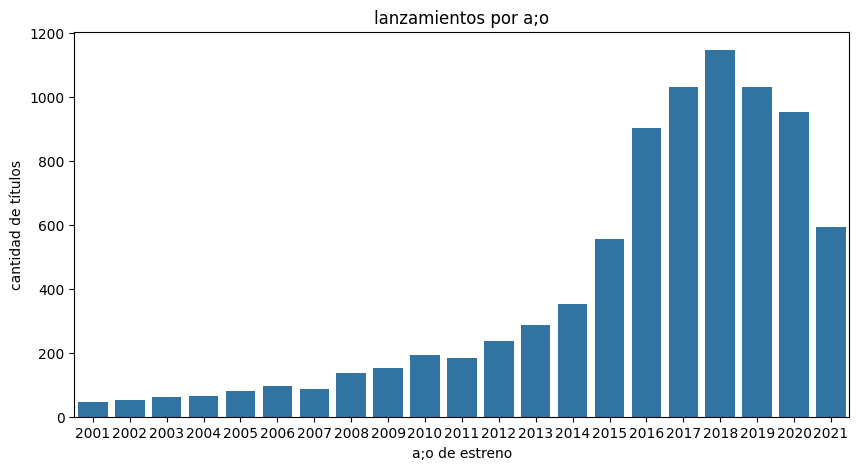

In [50]:
plt.figure(figsize=(10,5))

sns.countplot(data=df_recent, x="release_year")

plt.title("lanzamientos por a;o")
plt.xlabel("a;o de estreno")
plt.ylabel("cantidad de títulos")

plt.show()

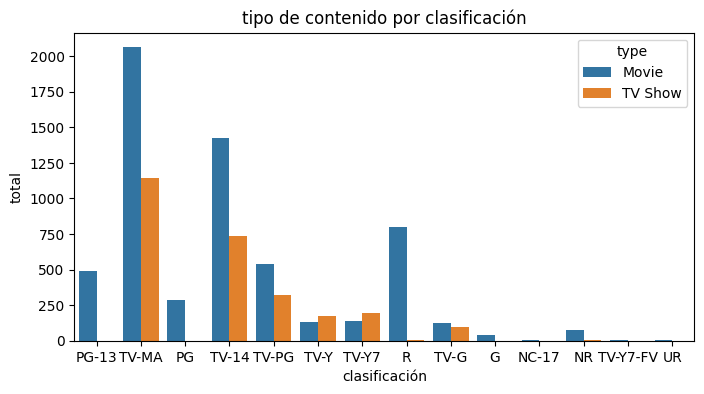

In [49]:
plt.figure(figsize=(8,4))

top_ratings = df['rating']
df_top_ratings = df[df['rating'].isin(top_ratings)]

sns.countplot(data=df_top_ratings, x="rating", hue="type")

plt.title("tipo de contenido por clasificación")
plt.xlabel("clasificación")
plt.ylabel("total")

plt.show()

In [51]:
# 4 Interpretacion de patrones (CAPA DE CONOCIMIENTO)
# Escribe al menos 3 conclusiones derivadas del analisis

1. como plantee antes al rellenar el date_added, conforme mas lanzamientos empezaron a haber, la industria en general empezo a producir mas contenido siendo a partir de 2015 el punto de produccion masiva
   
2. durante el confinamiento de 2020, se dificulto mucho la grabacion de productos, por lo que durante 2021 (que es hasta donde llegan los registros) los productos generados disminucieron drasticamente
   
3. se han hecho historicamente mas peliculas que series

4. acabo de recordar es un dataset de netflix, no es tanto por la industria, el boom es porque en ese momento netlfix nacio colo conocemos ahora

SyntaxError: invalid syntax (2514102745.py, line 4)